In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: For better chart styling
plt.style.use('ggplot')
sns.set_palette('coolwarm')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


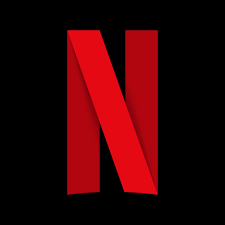 Netflix dataset loaded successfully!"

In [ ]:
import pandas as pd

file_path = '//content/Netflix Dataset.csv'
netflix = pd.read_csv(file_path)
netflix.head()


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [ ]:

netflix.info()


netflix.describe(include='all')


netflix.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


,0
Show_Id,0
Category,0
Title,0
Director,2388
Cast,718
Country,507
Release_Date,10
Rating,7
Duration,0
Type,0


In [ ]:
netflix['Director'].fillna('Unknown', inplace=True)
netflix['Cast'].fillna('Unknown', inplace=True)
netflix['Country'].fillna('Unknown', inplace=True)


# Data **Cleaning**

Convert the Release_Date column to datetime

In [ ]:
netflix['Release_Date'] = pd.to_datetime(netflix['Release_Date'], errors='coerce')
netflix['Year'] = netflix['Release_Date'].dt.year


Clean up inconsistent categories (like spacing or case differences)

In [ ]:
netflix['Category'] = netflix['Category'].str.strip()
netflix['Type'] = netflix['Type'].str.strip()


# Analysis & Visualization


(a) Movies vs TV Shows distribution

/tmp/ipython-input-3688431049.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=netflix, palette='viridis')


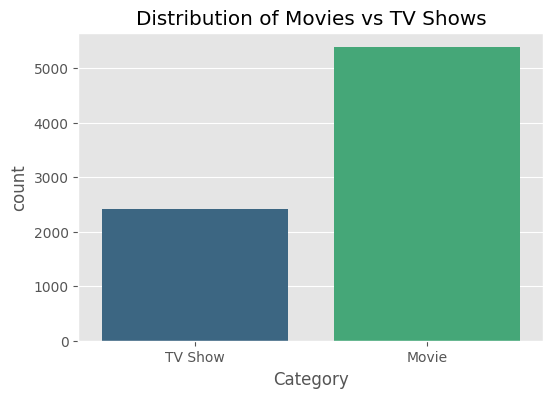

,count
Category,
Movie,5379
TV Show,2410


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Category', data=netflix, palette='viridis')
plt.title('Distribution of Movies vs TV Shows')
plt.show()

netflix['Category'].value_counts()


(b) Number of releases per year

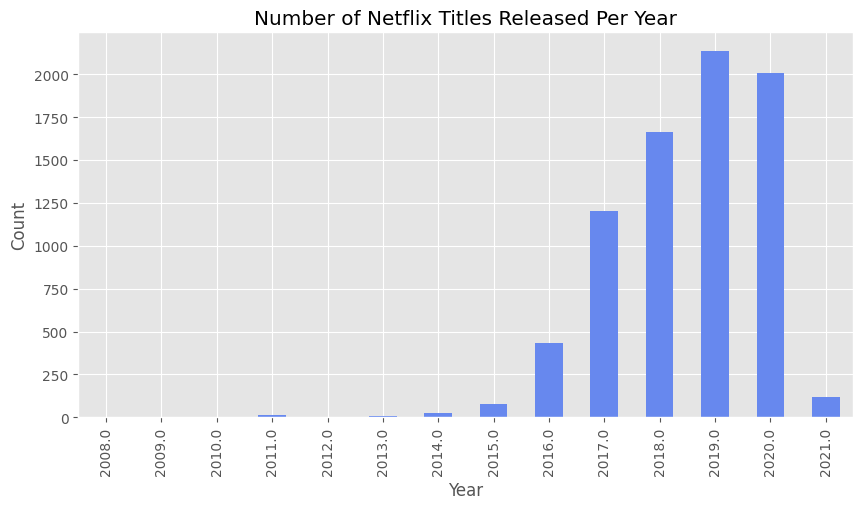

In [ ]:
plt.figure(figsize=(10,5))
netflix['Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Netflix Titles Released Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


(c) Top 10 Countries contributing content

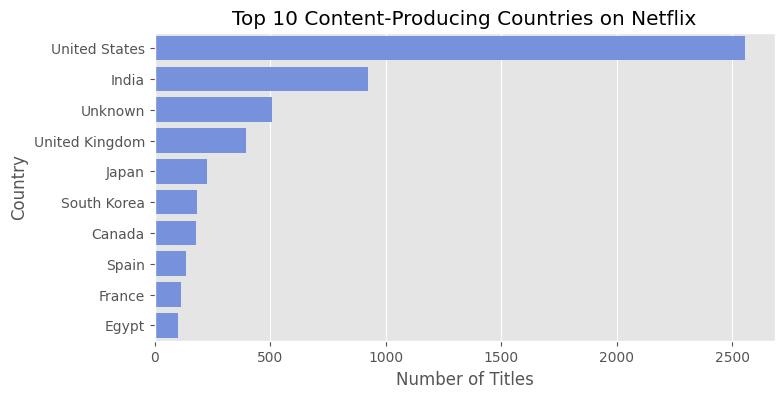

In [ ]:
top_countries = netflix['Country'].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Content-Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()


(d) Most common genres (from “Type” column)

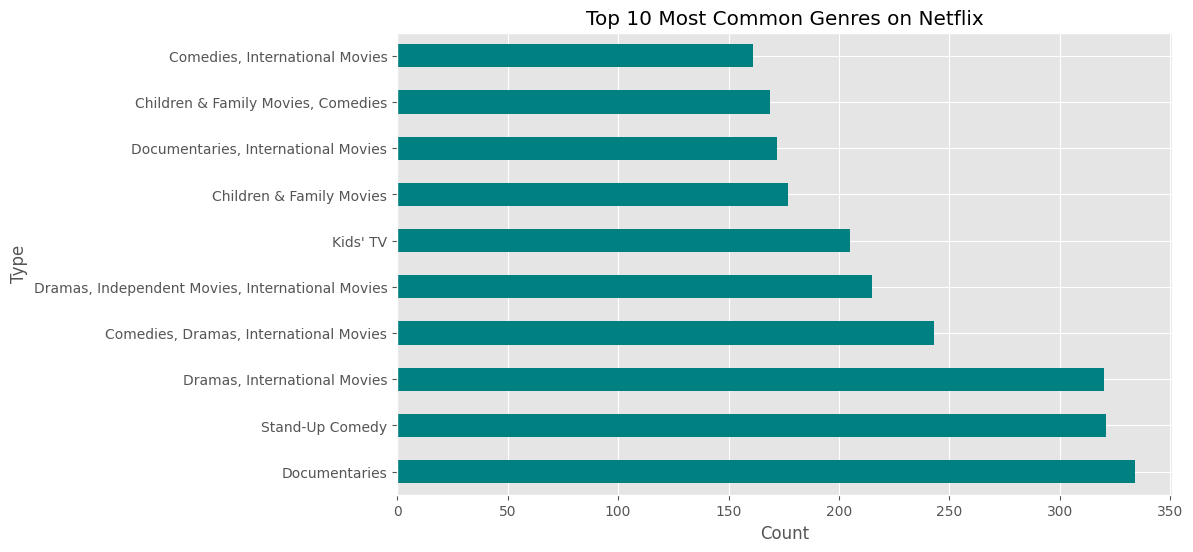

In [ ]:
plt.figure(figsize=(10,6))
netflix['Type'].value_counts().head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Count')
plt.show()


(e) Trend of Movies vs TV Shows over time

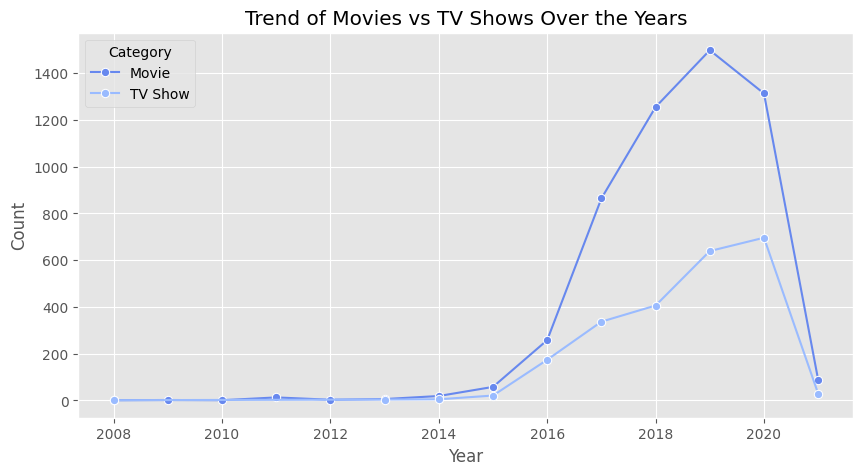

In [ ]:
category_year = netflix.groupby(['Year', 'Category']).size().reset_index(name='Count')

plt.figure(figsize=(10,5))
sns.lineplot(data=category_year, x='Year', y='Count', hue='Category', marker='o')
plt.title('Trend of Movies vs TV Shows Over the Years')
plt.show()


# Insights & Findings

After analyzing the Netflix dataset, several key trends and patterns were identified. These insights help us understand Netflix’s content distribution, production focus, and global expansion strategy.

 **1. Category Dominance: Movies vs. TV Shows**

Movies dominate Netflix’s library, accounting for roughly 65–70% of the total titles.

While TV Shows have grown significantly in recent years, Movies still make up the majority of content.

This indicates Netflix’s foundation was built on movies, but its future strategy leans increasingly toward original TV content.

**2. Year-wise Release Trends**

A steady growth in content production was observed until 2016, after which there was a sharp rise in the number of releases.

The peak year for releases appears to be 2019, before the pandemic period affected global production.

The post-2015 surge reflects Netflix’s global expansion and investment in original programming.



**3. Country-wise Production**

United States leads as the top content producer, followed by India and the United Kingdom.

This reflects Netflix’s strong market presence in the US and its increasing focus on Asian markets, especially India, where local language content is rapidly growing.

Other notable contributors include Canada, Japan, and South Korea, indicating Netflix’s diversified production network.

**4. Popular Genres**

The most frequent genres are Dramas, Documentaries, and Comedies.

Drama dominates both Movies and TV Shows, highlighting audience preference for storytelling and character-driven content.

The rising number of Documentaries shows Netflix’s focus on real-world stories and educational entertainment.

Genres like Sci-Fi, Horror, and Animation remain underrepresented but show strong niche potential.

**5. Recent Production Trends**

In the past few years, Netflix has increased its production of TV Shows, especially original series.

The shift aligns with changing viewer habits — audiences prefer binge-worthy, serialized storytelling.

This trend shows Netflix’s evolution from a movie-streaming platform to a global content creator and distributor with an emphasis on TV franchises.

# 7. Recommendations (Strategic Takeaways)

Based on the above findings, the following recommendations can help Netflix strengthen its global market position and content strategy:

**1. Expand TV Show Production in Emerging Markets**

Since TV shows are gaining popularity, Netflix should invest in producing more regional series in countries like India, South Korea, and Brazil.

These markets have high engagement with localized storytelling and large streaming audiences.

Collaborating with local creators and studios can boost cultural authenticity and viewer loyalty.
**2. Diversify Genre Portfolio**

While Drama and Documentary genres are strong, Netflix should expand underrepresented genres such as Science Fiction, Animation, Fantasy, and Thriller.

These genres attract younger audiences and fans of immersive storytelling, offering opportunities for cross-platform franchises.

**3. Strengthen Localization & Regional Content**

Localization (subtitles, dubbing, and culturally relevant storytelling) should be a key priority to reach non-English-speaking audiences.

Region-specific originals — e.g., K-dramas, Indian crime thrillers, or Spanish teen dramas — have proven to perform globally.

**4. Optimize Content Renewal Strategy**

Use data analytics to identify high-performing titles by viewership and retention rates.

Renew licenses or create sequels/spin-offs of top-performing categories to maintain audience engagement.

For older, underperforming content, consider phasing out or repurposing content in new bundles.

**5. Balance Movies and Series Portfolio**

Continue adding movies for casual viewers but focus long-term growth on serialized TV content that keeps users subscribed.

Short-format mini-series can also appeal to time-sensitive audiences while retaining storytelling quality.

# Summary

Netflix’s content library is still dominated by Movies, but the growth momentum lies in TV Shows and Originals.
To stay competitive, Netflix should leverage data trends, invest in regional TV content, and diversify genres to capture the next wave of global streaming audiences.